# 🏥 Healthcare Dataset — Exploratory Data Analysis

This notebook explores a healthcare dataset from Kaggle with **55,500 patient records** and 15 features. The goal is to uncover trends in patient demographics, medical conditions, billing, admissions, and test results.

**Dataset Features:** Name, Age, Gender, Blood Type, Medical Condition, Date of Admission, Insurance Provider, Billing Amount, Admission Type, Discharge Date, Medication, Test Results

**Tools Used:** Python · Pandas · NumPy · Matplotlib · Seaborn · Plotly · SciPy

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## 1. Imports & Setup

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Import Data set
healthcare_df = pd.read_csv(r"C:\Users\hp\Documents\Data Science\AltSchool Africa\Second Semester\healthcare_dataset.csv")
healthcare_df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## 2. Load Data

In [4]:
healthcare_df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

In [5]:
# Check the datatypes and shape 
healthcare_df.shape
healthcare_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [6]:
# create a pipleline of the original data

healthcare_df1 = healthcare_df.copy()

## 3. Data Cleaning & Preprocessing

Steps: check nulls, drop duplicates, remove irrelevant columns, convert date columns, engineer `Stay Duration`.

In [7]:
# Check for null values 
healthcare_df1.isna().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [8]:
# Check for duplicates and drop if necessary 
healthcare_df1.duplicated().sum()

np.int64(534)

In [9]:
healthcare_df1.drop_duplicates(inplace=True)

In [10]:
# Remove unnecessary columns in the data

healthcare_df1.drop(columns=['Doctor', 'Hospital', 'Room Number'], axis=1, inplace=True)
healthcare_df1.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Blue Cross,18856.281306,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Medicare,33643.327287,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Aetna,27955.096079,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Medicare,37909.782410,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Aetna,14238.317814,Urgent,2022-10-09,Penicillin,Abnormal


In [49]:
# Summary statistics of data
healthcare_df1.describe()

,Age,Date of Admission,Billing Amount,Discharge Date,Stay Duration (Days)
count,54966.000000,54966,54966.000000,54966,54966.000000
mean,51.535185,2021-11-01 17:35:29.505512448,25544.306284,2021-11-17 05:34:28.202161408,15.499290
min,13.000000,2019-05-08 00:00:00,-2008.492140,2019-05-09 00:00:00,1.000000
25%,35.000000,2020-07-28 00:00:00,13243.718641,2020-08-13 00:00:00,8.000000
50%,52.000000,2021-11-02 00:00:00,25542.749145,2021-11-18 00:00:00,15.000000
75%,68.000000,2023-02-03 00:00:00,37819.858159,2023-02-19 00:00:00,23.000000
max,89.000000,2024-05-07 00:00:00,52764.276736,2024-06-06 00:00:00,30.000000
std,19.605661,NaN,14208.409711,NaN,8.661471


In [11]:
# Convert Date of Admission and Discharge Date to datetime data

healthcare_df1['Date of Admission'] = pd.to_datetime(healthcare_df1['Date of Admission'])
healthcare_df1['Discharge Date'] = pd.to_datetime(healthcare_df1['Discharge Date'])
healthcare_df.head(2)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive


In [12]:
healthcare_df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54966 entries, 0 to 55499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                54966 non-null  object        
 1   Age                 54966 non-null  int64         
 2   Gender              54966 non-null  object        
 3   Blood Type          54966 non-null  object        
 4   Medical Condition   54966 non-null  object        
 5   Date of Admission   54966 non-null  datetime64[ns]
 6   Insurance Provider  54966 non-null  object        
 7   Billing Amount      54966 non-null  float64       
 8   Admission Type      54966 non-null  object        
 9   Discharge Date      54966 non-null  datetime64[ns]
 10  Medication          54966 non-null  object        
 11  Test Results        54966 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(8)
memory usage: 5.5+ MB


In [13]:
# Compute length of stay

healthcare_df1['Stay Duration (Days)'] = (healthcare_df1['Discharge Date'] - healthcare_df1['Date of Admission']).dt.days
healthcare_df1.head(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results,Stay Duration (Days)
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Blue Cross,18856.281306,Urgent,2024-02-02,Paracetamol,Normal,2
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Medicare,33643.327287,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Aetna,27955.096079,Emergency,2022-10-07,Aspirin,Normal,15
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Medicare,37909.782410,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Aetna,14238.317814,Urgent,2022-10-09,Penicillin,Abnormal,20


In [14]:
# Check Outliers in the Billing Amount column

healthcare_df1['Billing Amount'].describe()

count    54966.000000
mean     25544.306284
std      14208.409711
min      -2008.492140
25%      13243.718641
50%      25542.749145
75%      37819.858159
max      52764.276736
Name: Billing Amount, dtype: float64

In [15]:
# What are rows that has negative values in Billing Amount column ?

negative_billing_amt = healthcare_df1[healthcare_df1['Billing Amount'] < 0]
negative_billing_amt.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results,Stay Duration (Days)
132,ashLEy ERIcKSoN,32,Female,AB-,Cancer,2019-11-05,Aetna,-502.507813,Urgent,2019-11-23,Penicillin,Normal,18
799,CHRisTOPHer wEiss,49,Female,AB-,Asthma,2023-02-16,Aetna,-1018.245371,Elective,2023-03-09,Penicillin,Inconclusive,21
1018,AsHley WaRnER,60,Male,A+,Hypertension,2021-12-21,Aetna,-306.364925,Elective,2022-01-11,Ibuprofen,Normal,21
1421,JAY galloWaY,74,Female,O+,Asthma,2021-01-20,Blue Cross,-109.097122,Emergency,2021-02-09,Ibuprofen,Abnormal,20
2103,josHUa wilLIamSon,72,Female,B-,Diabetes,2021-03-21,Blue Cross,-576.727907,Urgent,2021-04-17,Aspirin,Abnormal,27


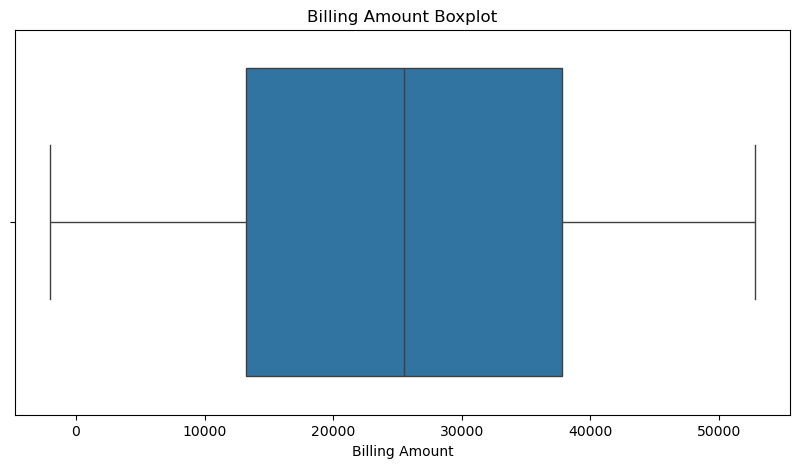

In [16]:
# visualize to check outliers/whiskers
plt.figure(figsize=(10,5))
sns.boxplot(x=healthcare_df1['Billing Amount'])
plt.title('Billing Amount Boxplot')
plt.show()

## 4. Univariate Analysis

Exploring individual features — age distribution, medical conditions, medications, and admission types.

In [17]:
# Check Which admission type is most common?

healthcare_df1['Admission Type'].value_counts()


Admission Type
Elective     18473
Urgent       18391
Emergency    18102
Name: count, dtype: int64

In [18]:
# Which medical conditions are most frequent?

healthcare_df1['Medical Condition'].value_counts()

Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64

In [19]:
# Which medications are most prescribed?

healthcare_df1['Medication'].value_counts()

Medication
Lipitor        11038
Ibuprofen      11023
Aspirin        10984
Paracetamol    10965
Penicillin     10956
Name: count, dtype: int64

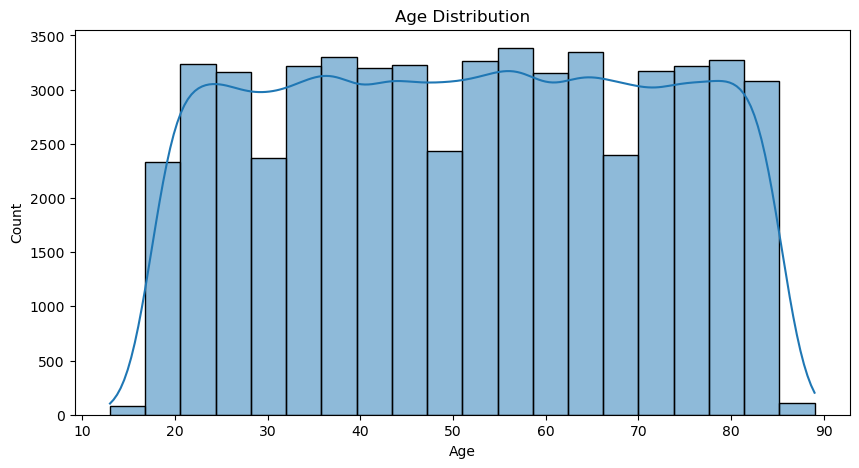

In [44]:
# visualize the age distribution

plt.figure(figsize=(10,5))
sns.histplot(x=healthcare_df1['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.savefig('AgeDis.png')
plt.show()

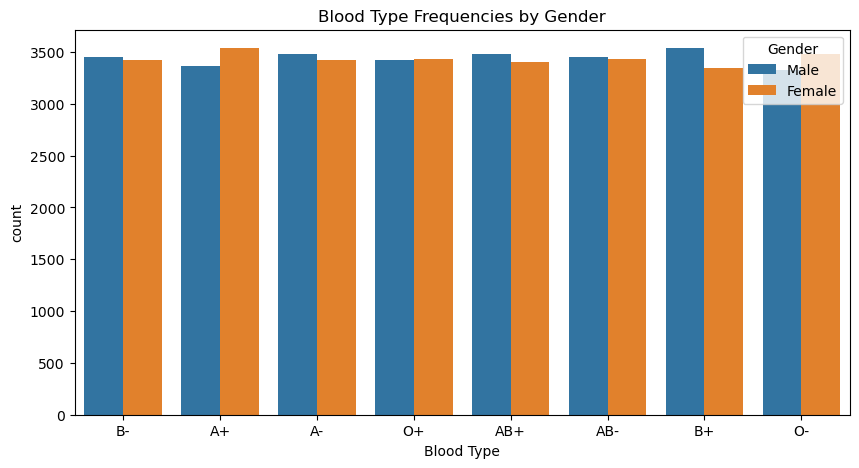

In [45]:
# check the blood type frequencies by gender

healthcare_df1.groupby('Gender')['Blood Type'].value_counts()
plt.figure(figsize=(10,5))
sns.countplot(x=healthcare_df1['Blood Type'], hue=healthcare_df1['Gender'])
plt.title('Blood Type Frequencies by Gender')
plt.savefig('BldTypFreq')
plt.show()

## 5. Bivariate & Group Analysis

Exploring relationships between features — blood type by gender, conditions by gender, and medication usage patterns.

In [22]:
# what is the distribution of medical conditions

healthcare_df1['Medical Condition'].value_counts()

Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64

In [23]:
# what gender is more affected by the disease

healthcare_df1.groupby('Medical Condition')['Gender'].value_counts(normalize=True)*100

Medical Condition  Gender
Arthritis          Female    50.357995
                   Male      49.642005
Asthma             Male      50.401319
                   Female    49.598681
Cancer             Male      50.043764
                   Female    49.956236
Diabetes           Female    50.010851
                   Male      49.989149
Hypertension       Male      50.071030
                   Female    49.928970
Obesity            Female    50.000000
                   Male      50.000000
Name: proportion, dtype: float64

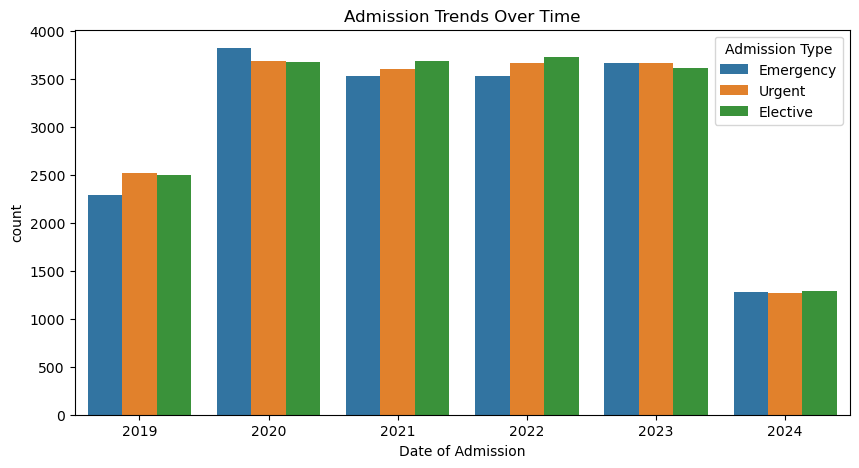

In [46]:
# Emergency vs Elective vs Urgent admissions: Admission trends over time

plt.figure(figsize=(10,5))
sns.countplot(x=healthcare_df1['Date of Admission'].dt.year, hue=healthcare_df1['Admission Type'])
plt.title('Admission Trends Over Time')
plt.savefig('AdmissionTrend')
plt.show()

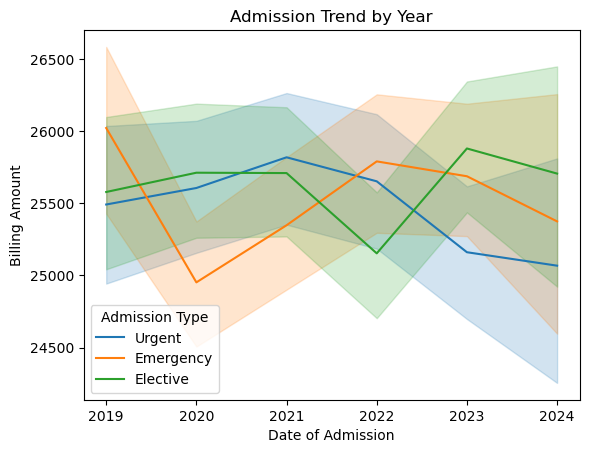

In [55]:
# Visualize the admission by year using a trend table

sns.lineplot(x=healthcare_df1['Date of Admission'].dt.year,
             hue=healthcare_df1['Admission Type'], y=healthcare_df1['Billing Amount'],
             data=healthcare_df1)
plt.title('Admission Trend by Year')
plt.savefig('TimeseriesTrend')
plt.show()

In [26]:
# Most common medical conditions and Medication usage patterns

healthcare_df1.groupby('Medication')['Medical Condition'].value_counts()


Medication   Medical Condition
Aspirin      Arthritis            1901
             Obesity              1853
             Hypertension         1845
             Diabetes             1836
             Asthma               1781
             Cancer               1768
Ibuprofen    Hypertension         1874
             Cancer               1862
             Diabetes             1846
             Obesity              1834
             Arthritis            1805
             Asthma               1802
Lipitor      Cancer               1904
             Diabetes             1875
             Hypertension         1823
             Asthma               1814
             Obesity              1812
             Arthritis            1810
Paracetamol  Asthma               1870
             Arthritis            1858
             Hypertension         1839
             Cancer               1829
             Diabetes             1794
             Obesity              1775
Penicillin   Obesity             

In [27]:
# What medications are most commonly used for each medical condition within each type of admission?

healthcare_df1.groupby(["Admission Type", "Medication", "Medical Condition"]).count()["Name"].unstack()

Medical Condition           Arthritis  Asthma  Cancer  Diabetes  Hypertension  \
Admission Type Medication                                                       
Elective       Aspirin            661     623     592       579           654   
               Ibuprofen          567     567     670       615           657   
               Lipitor            589     586     600       635           634   
               Paracetamol        612     654     667       610           644   
               Penicillin         633     639     585       592           593   
Emergency      Aspirin            631     552     600       588           582   
               Ibuprofen          649     613     562       590           596   
               Lipitor            579     617     650       608           599   
               Paracetamol        613     594     558       603           621   
               Penicillin         601     602     618       599           577   
Urgent         Aspirin            609     606     576       669           609   
               Ibuprofen          589     622     630       641           621   
               Lipitor            642     611     654       632           590   
               Paracetamol        633     622     604       581           574   
               Penicillin         610     587     574       674           600   

Medical Condition           Obesity  
Admission Type Medication            
Elective       Aspirin          631  
               Ibuprofen        618  
               Lipitor          591  
               Paracetamol      516  
               Penicillin       659  
Emergency      Aspirin          642  
               Ibuprofen        616  
               Lipitor          574  
               Paracetamol      653  
               Penicillin       615  
Urgent         Aspirin          580  
               Ibuprofen        600  
               Lipitor          647  
               Paracetamol      606  
               Penicillin       598

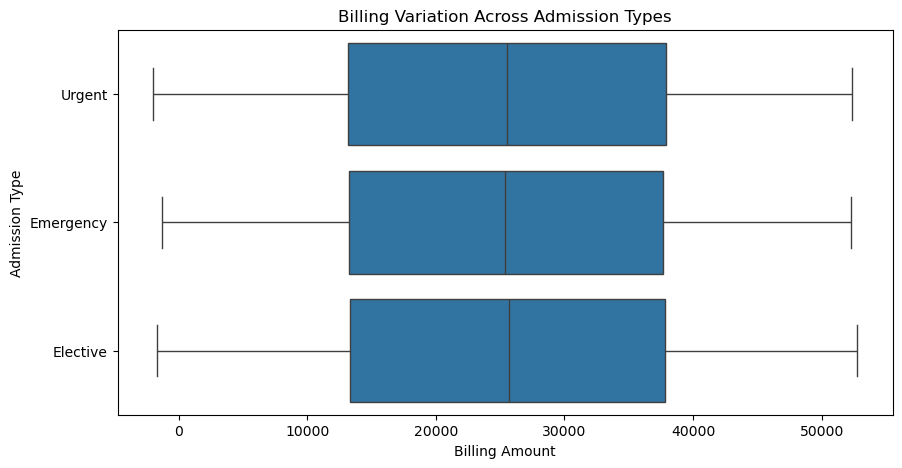

In [48]:
# Billing variation across admission types
# Billing by medical condition
# Billing dispersion

plt.figure(figsize=(10,5))
sns.boxplot(y=healthcare_df1['Admission Type'], x=healthcare_df1['Billing Amount'])
plt.title('Billing Variation Across Admission Types')
plt.savefig('BillingVariation')
plt.show()

## 6. Billing Analysis

How does billing vary across admission types, medical conditions, and length of stay?

In [29]:
# Billing vs length of stay: Does length of stay affect Billing amount

healthcare_df1.groupby('Stay Duration (Days)')['Billing Amount'].mean()

Stay Duration (Days)
1     25332.120731
2     25275.729178
3     25916.841521
4     26003.060271
5     25472.026206
6     25919.776421
7     25773.790664
8     26094.670590
9     25570.781016
10    25439.847493
11    25127.405957
12    25536.225436
13    24917.135479
14    26247.551479
15    25696.726889
16    25714.506582
17    25436.128867
18    24825.920424
19    25130.049841
20    25888.369619
21    25392.221824
22    25418.318335
23    25893.757902
24    25779.646243
25    25276.334343
26    25630.695421
27    25497.078109
28    25807.259257
29    24867.368933
30    25440.718142
Name: Billing Amount, dtype: float64

In [30]:
# check for abnormal test reuslts
abnormal_test_results = healthcare_df1[healthcare_df1['Test Results'] == 'Abnormal']
abnormal_test_results.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results,Stay Duration (Days)
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Medicare,37909.782410,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Aetna,14238.317814,Urgent,2022-10-09,Penicillin,Abnormal,20
8,JASmINe aGuIlaR,82,Male,AB+,Asthma,2020-07-01,Cigna,50119.222792,Elective,2020-07-14,Aspirin,Abnormal,13
12,connOR HANsEn,75,Female,A+,Diabetes,2019-12-12,Cigna,43282.283358,Emergency,2019-12-28,Penicillin,Abnormal,16
17,mRS. jamiE cAMPBELl,38,Male,AB-,Obesity,2020-03-08,Cigna,17440.465444,Urgent,2020-04-02,Paracetamol,Abnormal,25


In [31]:
# Are abnormal test results more common in certain conditions?
abnormal_test_results.groupby(['Medical Condition'])['Test Results'].value_counts()

Medical Condition  Test Results
Arthritis          Abnormal        3156
Asthma             Abnormal        2980
Cancer             Abnormal        3089
Diabetes           Abnormal        3131
Hypertension       Abnormal        2977
Obesity            Abnormal        3104
Name: count, dtype: int64

In [32]:
# Does length of stay vary by test result?
healthcare_df1.groupby('Test Results')['Stay Duration (Days)'].mean()

Test Results
Abnormal        15.508922
Inconclusive    15.452193
Normal          15.536359
Name: Stay Duration (Days), dtype: float64

## 7. Test Results Analysis

Examining abnormal test result patterns and their relationship to conditions, stay duration, and admission type.

Defining the Null Hypothesis: Test result outcomes depend on medical condition

In [34]:
# use Chi-square test of independence of variables in a contingency table to find relationship between Medical Condition vs Test Results
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(healthcare_df1['Medical Condition'], healthcare_df1['Test Results'])
contingency_table

Test Results,Abnormal,Inconclusive,Normal
Medical Condition,,,
Arthritis,3156,3062,3000
Asthma,2980,2999,3116
Cancer,3089,3033,3018
Diabetes,3131,3024,3061
Hypertension,2977,3068,3106
Obesity,3104,3012,3030


In [36]:
# Is there evidence that shows that Test result outcomes depend on medical condition

chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi-square statistic:", chi2)
print("p-value:", p)

Chi-square statistic: 13.271594720436372
p-value: 0.20888060455523685


👆Using a significance level of 5%, we would reject the null hypothesis in favor of the alternative hypothesis:
the outcome of the test results does not depend on the medical condition 

Defining the Null Hypothesis: Admission Type is Dependent on the Admission type

In [37]:
# Is there evidence that shows that Test result outcomes depend on Admission Type

contingency_table1 = pd.crosstab(healthcare_df1['Admission Type'], healthcare_df1['Test Results'])
contingency_table1

Test Results,Abnormal,Inconclusive,Normal
Admission Type,,,
Elective,6232,6054,6187
Emergency,6038,6020,6044
Urgent,6167,6124,6100


## 8. Statistical Testing (Chi-Square)

Using Chi-Square tests to assess independence between categorical variables.

In [38]:
chi2, p, dof, expected = chi2_contingency(contingency_table1)
print("Chi-square statistic:", chi2)
print("p-value:", p)

Chi-square statistic: 1.6483544800315115
p-value: 0.8000762990710856


##### 👆Using a significance level of 5%, we would reject the null hypothesis in favor of the alternative hypothesis:
the outcome of the test results is not significantly dependent on Admission Type 

Defining the Null Hypothesis: Admission type is dependent on the Gender of the patients

In [39]:
# Gender vs Admission Type chi square test

contingency_table2 = pd.crosstab(healthcare_df1['Gender'], healthcare_df1['Admission Type'])
contingency_table2

Admission Type,Elective,Emergency,Urgent
Gender,,,
Female,9281,9166,9023
Male,9192,8936,9368


In [41]:
chi2, p, dof, expected = chi2_contingency(contingency_table2)
print("Chi-square statistic:", chi2)
print("p-value:", p)

Chi-square statistic: 9.81073627944311
p-value: 0.0074067158746289104


👆Using a significance level of 5%, we would accept the null hypothesis ad reject the alternative hypothesis:
the outcome of the test results is dependent on Gender

## 9. Key Insights & Conclusions

- **Admission Types** are roughly equally distributed across Emergency, Elective, and Urgent — billing does not significantly differ by type.
- **Medical Conditions** (Cancer, Diabetes, Obesity, etc.) are evenly spread, suggesting a balanced dataset.
- **Gender** is statistically associated with Admission Type (Chi-Square test, p < 0.05), while Medical Condition and Test Results are *not* significantly linked.
- **Stay Duration** varies slightly by test result outcome, with Abnormal results associated with marginally longer stays.
- **Billing Amount** shows wide dispersion across all admission types, indicating patient-specific factors drive costs more than admission urgency.

> 📌 *This analysis is exploratory. Further modelling (e.g. regression on billing, classification of test results) could yield predictive insights.*